# Статистический анализ данных сервиса аренды самокатов GoFast

**Цель исследования:**
- Исследовать информацию о пользователях, преодоленном расстоянии и продолжительности поездок
- Произвести расчет помесячной выручки, которую принёс каждый пользователь
- Выяснить, тратят ли пользователи с подпиской больше времени на поездки?
- Выяснить правда ли то, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? 
- Выяснить будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?
- Выяснить, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 % и продлили подписку как минимум 100 существующих пользователей.
- Расчитать вероятность того, что если отдел маркетинга разошлет 1 миллион push-уведомлений, 399,5 тысяч пользователей их откроют.

**Ход исследования:**
Для проведения исследования у нас имеются 3 файла `users_go.csv` - содержит данные о пользователях сервиса GoFast, `rides_go.csv` - содержит данные о поездках пользователей, `subscriptions_go.csv` - содержит данные о типах и тарифах подписок. Эти файлы нам предстоит проверить на наличие пропусков, дубликатов, аномалий и ошибок.

Произведем общий обзор данных, приведем их в должный для проведения анализа вид, чтобы максимально исключить возможность искажения конечного результата исследования.

**Описание данных:**
`users_go.csv`
**user_id** - уникальный идентификатор пользователя
**name** - имя пользователя
**age** - возраст пользователя
**city** - город
**subscription_type** - тип подписки (free, ultra)

`rides_go.csv`
**user_id** - уникальный идентификатор пользователя
**distance** - расстояние, которое пользователь проехал в текущей сессии (в метрах)
**duration** - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
**date** - дата совершения поездки

`subscriptions_go.csv`
**subscription_type** - тип подписки
**minute_price** - стоимость одной минуты поездки по данной подписке
**start_ride_price** - стоимость начала поездки
**subscription_fee** - стоимость ежемесячного платежа

**Этапы исследования:**
- Загрузка и подготовка данных к анализу
- Исследовательский анализ данных
- Объединение данных
- Подсчет помесячной выручки
- Проверка гипотез
- Определение успешности поставленных задач

## Описание и предобработка данных

###  Загрузка данных

In [1]:
#импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import binom
from math import sqrt

Загрузим необходимые данные для дальнейшего анализа.

In [2]:
#выгрузим данные файлов с пользователями, поездками и подписками
try:
    users, rides, subscriptions = (
        pd.read_csv('/datasets/users_go.csv'),
        pd.read_csv('/datasets/rides_go.csv'),
        pd.read_csv('/datasets/subscriptions_go.csv')
    )
except:
    users, rides, subscriptions = (
        pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv'),
        pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv'),
        pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')
    )

Далее изучим общую информацию по трем датасетам. Для этого напишем собственную функцию.

In [3]:
#функция для изучения данных датафрейма
def show_info(df):
    display(df.head(5))
    print('----------')
    print(df.info())
    print('----------')
    print(df.describe())
    print('----------')
    print(df.isna().sum())
    print('----------')
    print(df.duplicated().sum())

In [4]:
#изучим датасет с пользователями
show_info(users)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None
----------
           user_id          age
count  1565.000000  1565.000000
mean    762.633866    24.922045
std     443.260155     4.553496
min       1.000000    12.000000
25%     378.000000    22.000000
50%     762.000000    25.000000
75%    1146.000000    28.000000
max    1534.000000    43.000000
----------
user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64
----------
31


Видим, что в датасете с пользователями отсутствуют пропуски, все типы данных соответствуют ожидаемым, среднее и медианное значение возраста очень близки, что говорит о том, что скорее всего в данных нет выбросов, что мы еще проверим. Видим также, что в датасете есть 31 явный дубликат.

In [5]:
#изучим датасет с поездками
show_info(rides)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None
----------
            user_id      distance      duration
count  18068.000000  18068.000000  18068.000000
mean     842.869936   3070.659976     17.805011
std      434.734317   1116.831209      6.091051
min        1.000000      0.855683      0.500000
25%      487.000000   2543.226360     13.597563
50%      889.000000   3133.609994     17.678395
75%     1213.250000   3776.222735     21.724800
max     1534.000000   7211.007745     40.823963
----------
user_id     0
distance    0
duration    0
date        0
dtype: int64
----------
0


В датасете с поездками также не наблюдается пропусков. В колонке `date` тип данных object не совпадает с ожидаемым форматом даты, в следующем шаге сделаем замену формата. Явные дубликаты не обнаружены. Средние значения и медианы в колонках `distance` и `duration` достаточно близки, что говорит об отсутствие выбросов, но минимальные значения говорят об обратном.

In [6]:
#изучим датасет с подписками
show_info(subscriptions)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes
None
----------
       minute_price  start_ride_price  subscription_fee
count      2.000000          2.000000          2.000000
mean       7.000000         25.000000         99.500000
std        1.414214         35.355339        140.714249
min        6.000000          0.000000          0.000000
25%        6.500000         12.500000         49.750000
50%        7.000000         25.000000         99.500000
75%        7.500000         37.500000        149.250000
max        8.000000         50.000000        199.000000
----------
subscription_type    

В датасете с подписками видим всего 2 строки с типами подписок. Пропусков нет, дубликатов нет, типы данных совпадают с ожидаемыми. Выбросов в данном датасете быть не может, так как здесь отражены данные с тарифами подписок, это установленные компанией значения, они неизменны. 

### Предобработка данных

Приступим к предобработке данных. 

**Работа с дубликатами**

Начнем с датасета с пользователями. Там мы обнаружили 31 явный дубликат. Избавимся от них.

In [7]:
#удаляем явные дубликаты
users = users.drop_duplicates().reset_index(drop=True)
#проверяем, успешно ли удалились дубликаты
users.duplicated().sum()

0

Явные дубликаты в датасете `users` успешно удалены. В остальных датасетах явных дубликатов нет.

Теперь проверим категоральные значения в таблице с пользователями: нет ли среди них неявных дубликатов или странных значений.

In [8]:
#проверяем значения колонки с именами
print(users['name'].unique())

['Кира' 'Станислав' 'Алексей' 'Константин' 'Адель' 'Регина' 'Игорь' 'Юрий'
 'Ян' 'Валерий' 'Агата' 'Марк' 'Ева' 'Антонина' 'Валерия' 'Амалия'
 'Даниил' 'Аделина' 'Святогор' 'Борис' 'Вероника' 'Ростислав' 'Назар'
 'Эдуард' 'Василий' 'Денис' 'Тамара' 'Николай' 'Эвелина' 'Федор' 'Руслан'
 'Иван' 'Любовь' 'Ярослава' 'Майя' 'Ильдар' 'Данила' 'Нина' 'Стефания'
 'Ясмина' 'Дмитрий' 'Александр' 'Одиссей' 'Арсений' 'Алла' 'Таисия'
 'Максим' 'Юлиана' 'Павел' 'Карина' 'Алиса' 'Лидия' 'Рамиль' 'Родион'
 'Ника' 'Оксана' 'Анастасия' 'Маргарита' 'Вера' 'Тимур' 'Никита' 'Лев'
 'Влад' 'Артур' 'Анна' 'Ольга' 'Вячеслав' 'Ксения' 'Виталина' 'Владислав'
 'Тамерлан' 'Амина' 'Вадим' 'Олеся' 'Зарина' 'Егор' 'Гордей' 'Лилия'
 'Святослав' 'Роберт' 'Амир' 'Влада' 'Богдан' 'Полина' 'Марат' 'Елисей'
 'Макар' 'Алина' 'Глеб' 'Андрей' 'Альбина' 'Людмила' 'Марсель' 'Милена'
 'Диана' 'Дарина' 'Данил' 'Артемий' 'Лиана' 'Альберт' 'Герман' 'Жанна'
 'Нелли' 'Евгения' 'Ариана' 'Самира' 'Захар' 'Эльвира' 'Екатерина' 'Инна'
 '

In [9]:
#проверяем значения колонки с городами
print(users['city'].unique())

['Тюмень' 'Омск' 'Москва' 'Ростов-на-Дону' 'Краснодар' 'Пятигорск'
 'Екатеринбург' 'Сочи']


In [10]:
#проверяем значения колонки с типом подписки
print(users['subscription_type'].unique())

['ultra' 'free']


Неявных дубликатов и необычных значений в категоральных столбцах фрейма с пользователями не обнаружено.

**Преобразование типов данных**

Приступим к проверке датасета с поездками `rides`. Ранее мы уже проверяли фрейм на наличие явных дубликатов и они не были обнаружены. Поскольку все данные в таблице количественные - неявные дубликаты так же исключаются. В этом датасете у нас неверный тип данных столбца `date`. Преобразуем тип данных в правильный.

In [11]:
#изменяем тип данных столбца date на datetime
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')
#проверим изменения типа данных
rides.dtypes

user_id              int64
distance           float64
duration           float64
date        datetime64[ns]
dtype: object

Тип данных в столбце `date` успешно изменен.

Проверим за какой период имеются данные во фрейме с поездками.

In [12]:
#выделим первую дату 
min_date = rides['date'].min()
#выделим последнюю дату
max_date = rides['date'].max()
#выводим
print(f'В таблице содержатся данные в период с {min_date} по {max_date}.')

В таблице содержатся данные в период с 2021-01-01 00:00:00 по 2021-12-30 00:00:00.


Во фрейме все данные за 2021 год, поэтому можем спокойно выделить столбец с месяцами.

Теперь в этой же таблице с поездками создадим столбец с месяцем поездки для дальнейшего анализа.

In [13]:
#создаем новый столбец month с номером месяца поездки
rides['month'] = pd.DatetimeIndex(rides['date']).month
#выведем первые 5 строк и проверим
display(rides.head(5))

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Столбец с месяцем поездки в датасете `rides` успешно создан.

**Проверка на наличие аномальных значений**

Проверим датасет с пользователями на наличие аномалий по количественным столбцам. Такой столбец в таблице только один - столбец с возрастом.

In [14]:
#смотрим значения возраста на аномалии
print(users['age'].unique())

[22 31 20 26 28 25 23 21 18 27 24 29 32 14 19 30 17 12 35 33 13 15 37 16
 34 38 36 39 43]


Все значения возраста в данном столбце соответствуют действительности.

Проверим датасет с поездками на наличие аномалий. Здесь внимание привлекают столбцы `distance` и `duration`. Для этих столбцов построим диаграммы размаха, чтобы увидеть наличие аномалий.

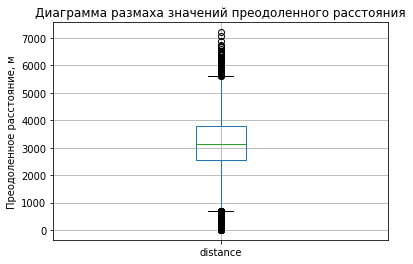

In [15]:
#строим диаграмму размаха для столбца distance
rides.boxplot(column=['distance'])
plt.ylabel('Преодоленное расстояние, м')
plt.title('Диаграмма размаха значений преодоленного расстояния')
plt.show()

Если смотреть по диаграмме, то видно, что аномальные значения принимаются ниже примерно 900м и выше 5600м. Минимальное значение расстояния примерно 0.86м, что действительно является странным. Такие низкие значения могут быть связаны с ошибкой приложения или же с тем, что пользователи отменяли поездки. Удалять такие значения мы не будем, так как они могут быть вполне реальны.

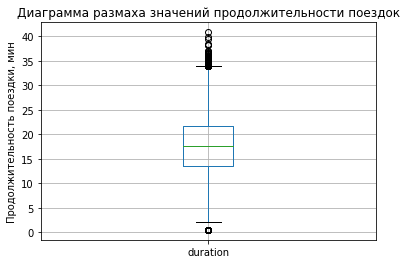

In [16]:
#строим диаграмму размаха для столбца duration
rides.boxplot(column=['duration'])
plt.ylabel('Продолжительность поездки, мин')
plt.title('Диаграмма размаха значений продолжительности поездок')
plt.show()

Диаграмма показывает, что аномальная продолжительность поездки меньше 2 минут и выше 34 минут. Видим несколько значений продолжительности поездки меньше 1 минуты. Минимальная продолжительность поездки 0.5 минуты. Такие аномалии удалять также не будем, так как пользователи могли и отменять поездки непосредственно после старта.

Датасет `subscriptions` проверять на аномалии и неявные дубликаты нет смысла, так как он содержит фиксированные тарифы подписок.

**Выводы по разделу:**
- Произвели загрузку и описание датасетов с пользователями, поездками и подписками.
- Нашли и удалили дубликаты в таблице `users` с пользователями. Неявных дубликатов не выявили ни в одной таблице.
- Пропуски в таблицах не обнаружены.
- В таблице `rides` заменили тип данных в столбце `date` с object на datetime и создали новый столбец с номером месяца поездки.
- В столбцах `distance` и `duration` были найдены очень низкие значения расстояния и продолжительности поездки. Такие значения мы не стали удалять, так как пользователи могли отменять поездки сразу после старта по разным причинам.

## Исследовательский анализ данных

Опишем и визуализируем общую информацию о пользователях и поездках. Для этого определим частоты встречаемости городов, посмотрим какое соотношение пользователей с подпиской и без, проанализируем возраст пользователей, расстояние, которое пользователь преодолел за одну поездку, и продолжительность поездок.

### Частота встречаемости городов

Посмотрим, в каких городах пользователи чаще всего пользуются самокатами.

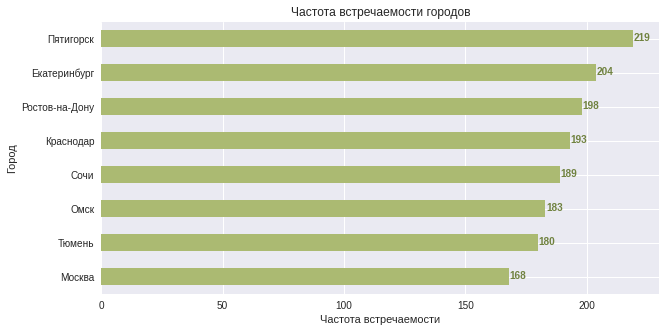

In [17]:
#строим диаграмму с частотой встречаемости городов
plt.style.use('seaborn')
fig, ax = plt.subplots()
top_cities = users['city'].value_counts().sort_values(ascending=True) \
                  .plot(kind='barh', y='city', grid=True, figsize=(10, 5), color='#ABBA72')

for i in ax.patches:
    plt.text(i.get_width()+0.2, i.get_y()+0.2,
             str(round((i.get_width()), 2)),
             fontsize=10, fontweight='bold',
             color='#708240')
    
plt.title('Частота встречаемости городов')
plt.ylabel('Город')
plt.xlabel('Частота встречаемости')
plt.show()

При общем взгляде на диаграмму можно сказать, что самокаты хорошо используются во всех городах. Тем не менее, в лидерах Пятигорск, Екатеринбург и Ростов-на-Дону. Отсайдером является Москва. Такая статистика крайне странная, так как в Москве можно встретить огромное количество людей на самокатах как в центре, так и за его пределами. Можем предположить, что в Москве большая конкуренция между сервисами, предоставляющими самокаты. Так же можем предположить, что такая популярность самокатов в Пятигорске может быть связана с тем, что город небольшой и в нем удобно перемещаться на самокатах, а также с меньшей конкуренцией. 

### Cоотношение пользователей с подпиской и без подписки

Проанализируем сколько процентов пользователей оформили подписку, а сколько - нет. Для этого построим круговую диаграмму.

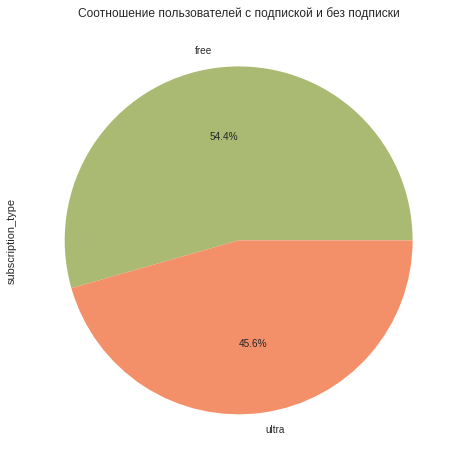

In [18]:
#строим круговую диаграмму с соотношением пользователей с подпиской и без
plt.style.use('seaborn')
subscribers_share = users['subscription_type'].value_counts() \
                    .plot(kind='pie', figsize=(10, 8), autopct='%1.1f%%', colors=['#ABBA72', '#F49069'])
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.show()

Всего пользователей, оформивших подписку 'Ultra', 45,6%, а пользователей без подписки - 54,4%. То есть, пользователей без подписки на 8,8% больше. В общем, соотношение получается почти пополам, что совсем неплохо. БОльшее количество пользователей без подписки может быть связано с тем, что они не осведомлены о наличии подписки, или же не так часто пользуются приложением и арендой самокатов, в связи с чем в ней не нуждаются.

### Возраст пользователей

Посмотрим распределение возраста пользователей, использующих приложение GoFast. Для этого отобразим гистограмму.

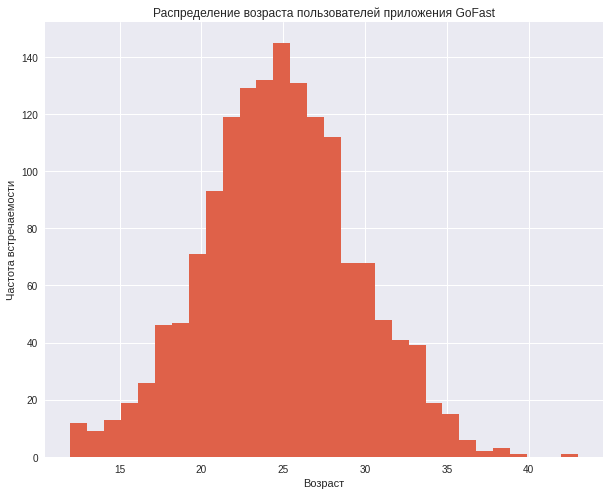

In [19]:
#строим гистограмму с распределением возраста пользователей
plt.style.use('seaborn')
age_distr = users['age'].plot(kind='hist', bins=30, grid=True, figsize=(10,8), color='#DF6149')
plt.title('Распределение возраста пользователей приложения GoFast')
plt.xlabel('Возраст')
plt.ylabel('Частота встречаемости')
plt.show()

На гистограмме видим, что бОльшая часть пользователей приложения находятся в диапазоне с возрастом от 17 до 33 лет. Самый часто встречаемый возраст - 25 лет. Минимальный возраст 12 лет, максимальный - 43 года. Сделаем вывод, что у приложения молодая аудитория.

### Расстояние, которое пользователь преодолел за одну поездку

Посмотрим распределение расстояния, которое преодолевают пользователи приложения, за одну поездку.

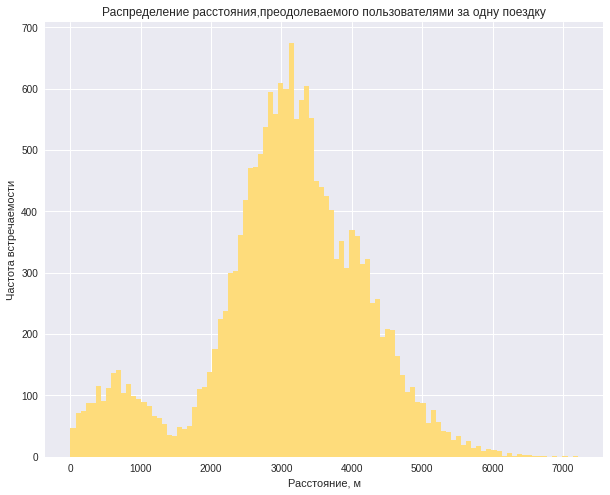

In [20]:
#строим гистограмму с распределением преодоленного расстояния
plt.style.use('seaborn')
distance_distr = rides['distance'].plot(kind='hist', bins=100, grid=True, figsize=(10,8), color='#FEDC7B')
plt.title('Распределение расстояния,преодолеваемого пользователями за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Частота встречаемости')
plt.show()

Расстояние, преодолеваемое пользователями за одну поездку, в среднем распределяется в диапазоне от примерно 2800м до 3400м (2,8км-3,4км). Также небольшие пики видны в области 500м. Самое часто встречаемое расстояние - 3200м (3,2км).

### Продолжительность поездок

Посмотрим, сколько в среднем длится одна поездка.

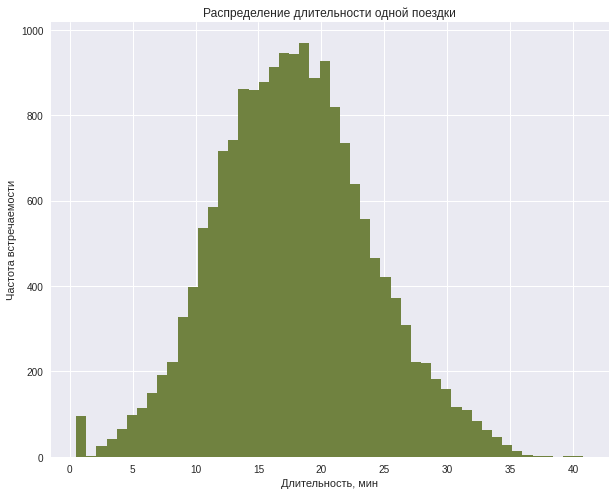

In [21]:
#строим гистограмму с распределением длительности одной поездки
plt.style.use('seaborn')
duration_distr = rides['duration'].plot(kind='hist', bins=50, grid=True, figsize=(10,8), color='#708240')
plt.title('Распределение длительности одной поездки')
plt.xlabel('Длительность, мин')
plt.ylabel('Частота встречаемости')
plt.show()

В среднем длительность одной поездки пользователей длится от 15 до 20 минут. Скорее всего за это время как раз и преодолевается среднее расстояние в 2,8-3,4 км.

**Вывод по разделу:**
- Самокаты хорошо используются во всех городах. Тем не менее, в лидерах Пятигорск, Екатеринбург и Ростов-на-Дону. Отсайдером является Москва. Такая статистика крайне странная, так как в Москве можно встретить огромное количество людей на самокатах как в центре, так и за его пределами. Можем предположить, что в Москве большая конкуренция между сервисами, предоставляющими самокаты. Так же можем предположить, что такая популярность самокатов в Пятигорске может быть связана с тем, что город небольшой и в нем удобно перемещаться на самокатах, а также с меньшей конкуренцией.
- Всего пользователей, оформивших подписку 'Ultra', 45,6%, а пользователей без подписки - 54,4%. То есть, пользователей без подписки на 8,8% больше. БОльшее количество пользователей без подписки может быть связано с тем, что они не осведомлены о наличии подписки, или же не так часто пользуются приложением и арендой самокатов, в связи с чем в ней не нуждаются.
- БОльшая часть пользователей приложения находятся в диапазоне с возрастом от 17 до 33 лет. Самый часто встречаемый возраст - 25 лет. Сделаем вывод, что у приложения молодая аудитория.
- Расстояние, преодолеваемое пользователями за одну поездку, в среднем распределяется в диапазоне от примерно 2800м до 3400м (2,8км-3,4км). Самое часто встречаемое расстояние - 3200м (3,2км).
- В среднем длительность одной поездки пользователей длится от 15 до 20 минут. Скорее всего за это время как раз и преодолевается среднее расстояние в 2,8-3,4 км.

## Объединение данных

### Объединим таблицы в один датафрейм

Для дальнейшего анализа будет удобнее объединить все данные вместе. Нам необходимо объединить таблицы `users`, `rides` и `subscriptions`. Для этого используем метод `merge`.

In [22]:
#объединяем таблицы users и rides
data = users.merge(rides, on='user_id', how='inner')
#теперь присоединим subscriptions
data = data.merge(subscriptions, on='subscription_type', how='inner')
#проверим объединение, выведем первые 10 строк фрейма
display(data.head(10))

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,2021-11-22,11,6,0,199


На первый взгляд все в порядке после присоединения. Посмотрим теперь общую информацию.

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month              18068 non-null  int64         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Пропусков нет, задвоенных столбцов тоже нет, типы данных в порядке. Объединение прошло успешно.

Теперь создадим два датафрейма из общего датафрейма `date`. В первом будут только пользователи с подпиской, а во втором - без подписки.

In [24]:
#создаем датафрейм с пользователями с подпиской
data_ultra = data.query('subscription_type == "ultra"')
#выведем первые 5 строк
data_ultra.head(5)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [25]:
#создаем датафрейм с пользователями без подписки
data_free = data.query('subscription_type == "free"')
#выведем первые 5 строк
data_free.head(5)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


Два датафрейма с подписками и без созданы.

### Расстояние и время поездок с разбивкой по типу подписки

**Расстояние, которое пользователь преодолел за одну поездку, с разбивкой по типу подписки**

Посмотрим на распределение расстояния, которое преодолевают за одну поездку пользователи с подпиской и без нее.

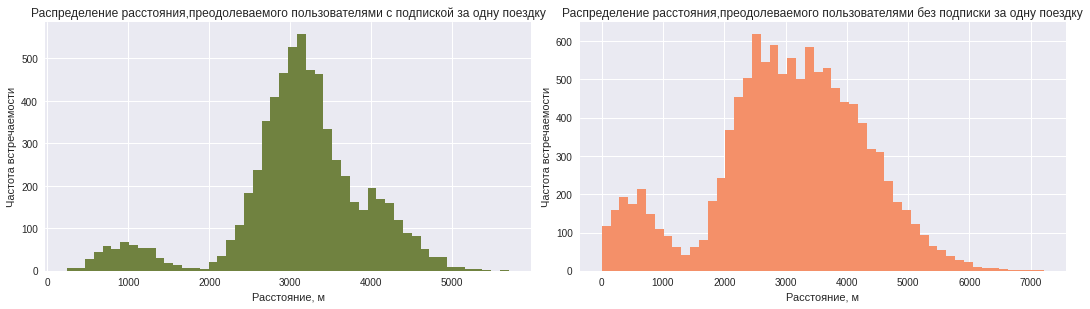

In [26]:
plt.style.use('seaborn')

#строим гистограмму с распределением преодоленного расстояния пользователей с подпиской
ax1 = plt.subplot(2, 2, 1)
distance_distr_ultra = data_ultra['distance'].plot(kind='hist', bins=50, grid=True, figsize=(15,8), color='#708240', ax=ax1)
plt.title('Распределение расстояния,преодолеваемого пользователями с подпиской за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Частота встречаемости')

#строим гистограмму с распределением преодоленного расстояния пользователей без подписки
ax2 = plt.subplot(2, 2, 2)
distance_distr_free = data_free['distance'].plot(kind='hist', bins=50, grid=True, figsize=(15,8), color='#F49069', ax=ax2)
plt.title('Распределение расстояния,преодолеваемого пользователями без подписки за одну поездку')
plt.xlabel('Расстояние, м')
plt.ylabel('Частота встречаемости')

plt.tight_layout()
plt.show()

Распределение преодоленного расстояния у пользователей с подпиской в среднем составляет 3000-3200 м (3-3,2 км), а у пользователей без подписки - 2500-3600 м (2,5-3,6 км). При этом количество пользователей преодолевших расстояние меньше 1 км и больше 4 км среди неимющих подписку больше, чем среди имеющих. То есть, исходя из гистограмм, пользователи без подписки в среднем преодолевают большие расстояния, чем пользователи с подписками.

**Время поездок пользователей с разбивкой по типу подписки**

Как же распределяется время поездки пользователей с разбивкой по типу подписки? Построим гистограммы и посмотрим.

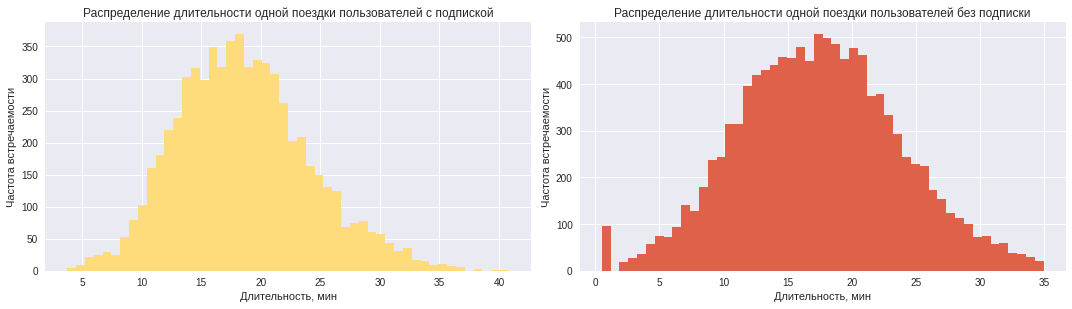

In [27]:
plt.style.use('seaborn')

#строим гистограмму с распределением времени поездки пользователей с подпиской
ax1 = plt.subplot(2, 2, 1)
duration_distr_ultra = data_ultra['duration'].plot(kind='hist', bins=50, grid=True, figsize=(15,8), color='#FEDC7B', ax=ax1)
plt.title('Распределение длительности одной поездки пользователей с подпиской')
plt.xlabel('Длительность, мин')
plt.ylabel('Частота встречаемости')

#строим гистограмму с распределением преодоленного расстояния пользователей без подписки
ax2 = plt.subplot(2, 2, 2)
duration_distr_free = data_free['duration'].plot(kind='hist', bins=50, grid=True, figsize=(15,8), color='#DF6149', ax=ax2)
plt.title('Распределение длительности одной поездки пользователей без подписки')
plt.xlabel('Длительность, мин')
plt.ylabel('Частота встречаемости')

plt.tight_layout()
plt.show()

Средняя длительность поездки у пользователей с подпиской находится в диапазоне 13-22 минут, а у пользователей без подписки - 12-21 минута. То есть средняя длительность у обоих категорий пользователей примерно одинаковая. Стоит отметить, что среди пользователей с подписками поездки с длительностью более 35 минут, среди пользователей без подписок - нет. Так же около 100 пользователей без подписки совершали поездки длительностью меньше 1 минуты. 

**Вывод по разделу:**
- Обединили три первоначальных датафрейма с данными о пользователях, поездках и подписках в один датафрейм `data`.
- На базе датафрейма `data` создали два датафрейма: `data_ultra` - с информацией о пользователях с подпиской, `data_free` - с информацией о пользователях без подписки.
- Проанализировали расстояние и длительность поездки пользователей с разбивкой по типу подписки.
- Распределение преодоленного расстояния у пользователей с подпиской в среднем составляет 3000-3200 м (3-3,2 км), а у пользователей без подписки - 2500-3600 м (2,5-3,6 км). При этом количество пользователей преодолевших расстояние меньше 1 км и больше 4 км среди неимющих подписку больше, чем среди имеющих. То есть, пользователи без подписки в среднем преодолевают бОльшие расстояния, чем пользователи с подписками.
- Средняя длительность поездки у пользователей с подпиской находится в диапазоне 13-22 минут, а у пользователей без подписки - 12-21 минута. То есть средняя длительность у обоих категорий пользователей примерно одинаковая. Стоит отметить, что среди пользователей с подписками поездки с длительностью более 35 минут, среди пользователей без подписок - нет. Так же около 100 пользователей без подписки совершали поездки длительностью меньше 1 минуты.

## Подсчёт выручки

Нам необходимо посчитать помесячную выручку, которую принес каждый пользователь. Для этого создадим аггрегированную таблицу, в столбцах которой будут суммарное расстояние, количество поездок, суммарная продолжительность поездок и тип подписки. Это поможет нам в дальнейшем расчете выручки.

In [28]:
#каждое значение из столбца duration округляем с помощью «потолка»
data['duration'] = np.ceil(data['duration']) 
#строим аггрегированную таблицу
data_agg_rides = (data.groupby(['month', 'user_id'])
                      .agg({'distance': 'sum',
                            'duration': 'sum',
                            'name': 'count',
                            'subscription_type': 'min'}))
#даем название колонкам
data_agg_rides.columns = ['total_distance', 'total_duration', 'rides_quantity', 'subscription_type']
 
#выведем первые 10 строк
data_agg_rides.head(10)

total_distance  total_duration  rides_quantity  \
month user_id                                                   
1     1           7027.511294            42.0               2   
      3           3061.777147            13.0               1   
      5           3914.646990            13.0               1   
      7           6478.080979            28.0               2   
      12          3577.151148            33.0               1   
      13          6687.987446            42.0               2   
      14          7699.643820            35.0               2   
      15          4187.621459            39.0               1   
      20          3516.719208            29.0               1   
      22          3058.692225            13.0               1   

              subscription_type  
month user_id                    
1     1                   ultra  
      3                   ultra  
      5                   ultra  
      7                   ultra  
      12                  ultra  
      13                  ultra  
      14                  ultra  
      15                  ultra  
      20                  ultra  
      22                  ultra

Для расчета помесячной выручки создадим свою функцию с расчетами.

In [29]:
#функция для расчета помесячной выручки
def rev_calc(df):
    if df['subscription_type'] == 'free':
        return (50 * df['rides_quantity']) + (8 * df['total_duration'])
    elif df['subscription_type'] == 'ultra':
        return (6 * df['total_duration']) + 199

In [30]:
#добавим новый столбец и применим функцию
data_agg_rides['monthly_revenue'] = data_agg_rides.apply(rev_calc, axis=1)
#для проверки выведем первых 10 строк фрейма
data_agg_rides.head(10)

total_distance  total_duration  rides_quantity  \
month user_id                                                   
1     1           7027.511294            42.0               2   
      3           3061.777147            13.0               1   
      5           3914.646990            13.0               1   
      7           6478.080979            28.0               2   
      12          3577.151148            33.0               1   
      13          6687.987446            42.0               2   
      14          7699.643820            35.0               2   
      15          4187.621459            39.0               1   
      20          3516.719208            29.0               1   
      22          3058.692225            13.0               1   

              subscription_type  monthly_revenue  
month user_id                                     
1     1                   ultra            451.0  
      3                   ultra            277.0  
      5                   ultra            277.0  
      7                   ultra            367.0  
      12                  ultra            397.0  
      13                  ultra            451.0  
      14                  ultra            409.0  
      15                  ultra            433.0  
      20                  ultra            373.0  
      22                  ultra            277.0

**Выводы по разделу:**
- Создали аггрегированную таблицу, в столбцах которой суммарное расстояние, количество поездок, суммарная продолжительность поездок и тип подписки.
- Произвели расчет помесячной выручки с каждого пользователя и добавили в таблицу столбец со значением посчитанной выручки.

## Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской, для чего они планируют проводить различные акции. Перед тем, как совершать эти действия, нам необходимо проверить несколько гипотез.

### Тратят ли пользователи с подпиской больше времени на поездки?

Нам необходимо понять, тратят ли пользователи с подпиской больше времени на поездки? Если это действительно так, то пользователи с подпиской могут быть «выгоднее» для компании.

**Сформулируем нулевую гипотезу (Н0):** пользователи с подпиской Ultra тратят в среднем столько же времени на поездки, сколько и пользователи без подписки.

**Сформулируем альтернативную гипотезу (Н1):** пользователи с подпиской Ultra тратят в среднем больше времени на поездки, чем пользователи без подписки.

Поскольку имеем две независимые генеральные совокупности, для проверки гипотезы используем метод `scipy.stats.ttest_ind`.

In [31]:
#проверяем гипотезу

#выведем среднюю продолжительность поездки пользователей с подпиской и без
print(f'Средняя продолжительность поездки пользователей с подпиской Ultra: {np.mean(data_ultra.duration)}')
print(f'Средняя продолжительность поездки пользователей без подписки: {np.mean(data_free.duration)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

results = st.ttest_ind(data_ultra['duration'], data_free['duration'], alternative = 'greater')

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средняя продолжительность поездки пользователей с подпиской Ultra: 18.54198516280583
Средняя продолжительность поездки пользователей без подписки: 17.39090929866399
р-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


В ходе проведения теста, нулевая гипотеза о том, что средняя продолжительность поездки пользователей с подпиской и без равна, была отвергнута в пользу альтернативной гипотезы. 

Среднее время поездки пользователей с подпиской составляет примерно 18,5 минут, а без подписки - примерно 17,4 минут. Получается разница в 1,1 минуты в пользу пользователей с подпиской. Разница не очень большая. Тем не менее, можем сказать, что пользователи с подпиской тратят больше времени на поездки.

### Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает оптимального с точки зрения износа самоката?

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

**Сформулируем нулевую гипотезу (Н0):** Пользователи с подпиской Ultra проезжают за одну поездку в среднем не больше 3130 метров.

**Сформулируем альтернативную гипотезу (Н1):** Пользователи с подпиской Ultra проезжают за одну поездку в среднем больше 3130 метров.


Для проверки гипотезы будем использовать метод `scipy.stats.ttest_1samp()`, так как наша гипотеза односторонняя и проврка проводится для одной выборки.

In [32]:
#проверяем гипотезу

#выведем среднее расстояние одной поездки пользователей с подпиской
print(f'Среднее расстояние одной поездки пользователей с подпиской Ultra: {np.mean(data_ultra.distance)}')

optimal_distance = 3130 #оптимальное расстояние

#обозначим уровень статистической значимости
alpha = 0.05

results = st.ttest_1samp(data_ultra['distance'], optimal_distance, alternative='greater')

#выведем полученное p-value
print('p-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Среднее расстояние одной поездки пользователей с подпиской Ultra: 3115.4453880370247
p-значение: 0.9195368847849785
Не отвергаем нулевую гипотезу


Проверили гипотезу о том, что среднее расстояние, преодоленное пользователями с подпиской, не превышает оптимальное расстояние в 3130 метров. На основе проведенного теста отвергнуть нулевую гипотезу мы не можем. Об этом нам говорит и расчитанное среднее расстояние, которое равно примерно 3115,45 метра.

### Выше ли помесячная выручка пользователей с подпиской, чем пользователей без подписки?

Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. 

**Сформулируем нулевую гипотезу (Н0):** Помесячная средняя выручка пользователей с подпиской Ultra равна помесячной выручке пользователей без подписки.

**Сформулируем альтернативную гипотезу (Н1):** Помесячная средняя выручка пользователей с подпиской Ultra выше, чем помесячная средняя выручка от пользователей без подписки.

Так как у нас снова присутствует две независимые генеральные совокупности, для проверки гипотезы используем метод `scipy.stats.ttest_ind()`.

In [33]:
#зададим переменные с помесячной выручкой от пользователей с подпиской и без
monthly_rev_ultra = data_agg_rides.loc[data_agg_rides["subscription_type"] == 'ultra']['monthly_revenue'] #выручка с подпиской
monthly_rev_free = data_agg_rides.loc[data_agg_rides["subscription_type"] == 'free']['monthly_revenue'] #выручка без подписки

#выведем среднюю помесячную выручку от пользователей с подпиской и без
print(f'Средняя помесячная выручка от пользователей с подпиской Ultra: {np.mean(monthly_rev_ultra)}')
print(f'Средняя помесячная выручка от пользователей без подписки: {np.mean(monthly_rev_free)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

results = st.ttest_ind(monthly_rev_ultra, 
                       monthly_rev_free, 
                       alternative = 'greater')

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средняя помесячная выручка от пользователей с подпиской Ultra: 362.7921906022502
Средняя помесячная выручка от пользователей без подписки: 328.6413651073845
р-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


На основе теста нулевую гипотезу о равенстве помесячной средней выручки от пользователей с подпиской и без пришлось отвергнуть. Средняя помесячная выручка от пользователей с подпиской составляет примерно 361,5 рублей, что на 35,7 рублей превышает среднюю помесячную выручку от пользователей без подписки, она составляет 325,8 рублей. То есть, можно сказать, что помесячная выручка от пользователей, имеющих подписку, больше, чем не имеющих подписку.

### Задача

Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

**Ответ:** Исходя из условия задачи, получается, что нам необходимо исследовать одну генеральную совокупность, с которой произошли некие изменения (в данном случае это обновление сервера). Таким образом, у нас получаются две зависимые (парные) выборки (обращения пользователей до обновления и после него). Чтобы проверить такую гипотезу, нам нужно провести Т-тест, используя метод `scipy.stats.ttest_rel(before, after, alternative='less')`.

**Выводы по разделу:**
-  Нулевая гипотеза о том, что средняя продолжительность поездки пользователей с подпиской и без равна, была отвергнута в пользу альтернативной гипотезы. Среднее время поездки пользователей с подпиской составляет примерно 18,5 минут, а без подписки - примерно 17,4 минут. Получается разница в 1,1 минуты в пользу пользователей с подпиской. Разница не очень большая. Тем не менее, можем сказать, что пользователи с подпиской тратят больше времени на поездки.
- Проверили гипотезу о том, что среднее расстояние, преодоленное пользователями с подпиской, не превышает оптимальное расстояние в 3130 метров. На основе проведенного теста отвергнуть нулевую гипотезу мы не можем. Об этом нам говорит и расчитанное среднее расстояние, которое равно примерно 3115,45 метра. То есть, можно сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает оптимального с точки зрения износа самоката.
- Нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без пришлось отвергнуть. Средняя помесячная выручка от пользователей с подпиской составляет примерно 361,5 рублей, что на 35,7 рублей превышает среднюю помесячную выручку от пользователей без подписки, она составляет 325,8 рублей. То есть, можно сказать, что помесячная выручка от пользователей, имеющих подписку, больше, чем не имеющих подписку.

## Распределения

### Акция "Бесплатный месяц подписки"

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. 

При раздаче промокодов в количестве 1161 вероятность не выполнить план составит 5.0 %


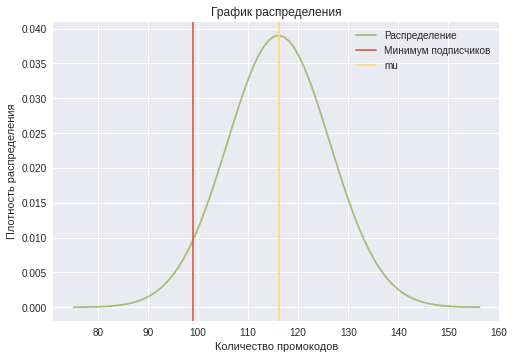

In [34]:
n = 1000
p = 0.1 #веротность того, что пользователи продлят подписку
k = 99 #минимальное количество пользователей, которые должны продлить подписку
binom_cdf = 0.05 #максимальная вероятность невыполнить план

while binom_cdf < binom.cdf(k, n, p):
    n += 1
print(f'При раздаче промокодов в количестве {n} вероятность не выполнить план составит {binom.cdf(k, n, p).round(2)*100} %')

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = (n * p * (1 - p))**0.5

arange = np.arange((mu - 4 * sigma),(mu + 4 * sigma),1)

plt.plot(arange, st.norm.pdf(arange, mu, sigma), 'b-', color='#ABBA72', label='Распределение')
plt.axvline(x=k, color='#DF6149', label='Минимум подписчиков')
plt.axvline(x=mu, color='#FEDC7B', label='mu')
plt.legend()
plt.title('График распределения')
plt.xlabel('Количество промокодов')
plt.ylabel('Плотность распределения')
plt.show()

Для того, чтобы минимум 100 пользователей продлили подписку в приложении с вероятностью не выполнить план примерно 5%, компании необходимо раздать как минимум 1161 промокода пользователям.

### Push-уведомления

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. Стоит задача оценить вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Вероятность того, что не более 399.5 тыс пользователей откроют уведомление составляет: 15.4 %


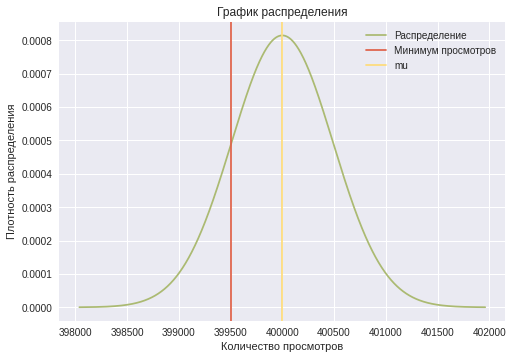

In [35]:
n = 1000000 #столько планируется разослать уведомлений
p = 0.4 #веротность того, что пользователи откроют уведомление
k = 399500 #сколько пользователей по плану должны открыть уведомлений

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = (n * p * (1 - p))**0.5


#задаём нормальное распределение
distr = st.norm(mu, sigma) 

#считаем вероятность хвоста слева от 399,5 тысяч
result = distr.cdf(k)
print(f'Вероятность того, что не более 399.5 тыс пользователей откроют уведомление составляет: {result.round(3) * 100} %')

arange = np.arange((mu - 4 * sigma),(mu + 4 * sigma),1)
plt.plot(arange, st.norm.pdf(arange, mu, sigma), 'b-', color='#ABBA72', label='Распределение')
plt.axvline(x=k, color='#DF6149', label='Минимум просмотров')
plt.axvline(x=mu, color='#FEDC7B', label='mu')
plt.legend()
plt.title('График распределения')
plt.xlabel('Количество просмотров')
plt.ylabel('Плотность распределения')
plt.show()

Если разослать 1 миллион push-уведомлений пользователям, то вероятность что их откроют не более 399,5 тысяч пользователей, составляет 15,4%.

**Вывод по разделу:**
- Для того, чтобы отдел маркетинга сервиса GoFast удачно провел акцию с рассылкой промокодов на месяц бесплатной подписки, в рамках которой продлить подписку должны как минимум 100 существующих пользователей, необходимо провести рассылку как минимум 1161 промокод. При этом вероятность не выполнить план составит 5%.
- При рассылке 1 миллиона push-уведомлений пользователям в приложении, вероятность того, что 399,5 тысяч пользователей их откроют составит 15,4%.

## Общие выводы

Нами был проведен статистический анализ данных популярного сервиса аренды самокатов GoFast.

В ходе анализа произвели загрузку и описание датасетов с пользователями, поездками и подписками. Нашли и удалили дубликаты в таблице `users` с пользователями. Неявных дубликатов не выявили ни в одной таблице. Пропуски в таблицах не обнаружены. В таблице `rides` заменили тип данных в столбце `date` с object на datetime и создали новый столбец с номером месяца поездки. В столбцах `distance` и `duration` были найдены очень низкие значения расстояния и продолжительности поездки. Такие значения мы не стали удалять, так как пользователи могли отменять поездки сразу после старта по разным причинам.

Нам удалось выяснить, что самокаты хорошо используются во всех городах. Тем не менее, в лидерах Пятигорск, Екатеринбург и Ростов-на-Дону. Отсайдером является Москва. Такая статистика крайне странная, так как в Москве можно встретить огромное количество людей на самокатах как в центре, так и за его пределами. Можем предположить, что в Москве большая конкуренция между сервисами, предоставляющими самокаты. Так же можем предположить, что такая популярность самокатов в Пятигорске может быть связана с тем, что город небольшой и в нем удобно перемещаться на самокатах, а также с меньшей конкуренцией.

Всего пользователей, оформивших подписку 'Ultra', 45,6%, а пользователей без подписки - 54,4%. То есть, пользователей без подписки на 8,8% больше. БОльшее количество пользователей без подписки может быть связано с тем, что они не осведомлены о наличии подписки, или же не так часто пользуются приложением и арендой самокатов, в связи с чем в ней не нуждаются.

БОльшая часть пользователей приложения находятся в диапазоне с возрастом от 17 до 33 лет. Самый часто встречаемый возраст - 25 лет. Сделаем вывод, что у приложения молодая аудитория.

Расстояние, преодолеваемое пользователями за одну поездку, в среднем распределяется в диапазоне от примерно 2800м до 3400м (2,8км-3,4км). Самое часто встречаемое расстояние - 3200м (3,2км).

В среднем длительность одной поездки пользователей длится от 15 до 20 минут. Скорее всего за это время как раз и преодолевается среднее расстояние в 2,8-3,4 км.

Распределение преодоленного расстояния у пользователей с подпиской в среднем составляет 3000-3200 м (3-3,2 км), а у пользователей без подписки - 2500-3600 м (2,5-3,6 км). При этом количество пользователей преодолевших расстояние меньше 1 км и больше 4 км среди неимющих подписку больше, чем среди имеющих. То есть, пользователи без подписки в среднем преодолевают бОльшие расстояния, чем пользователи с подписками.

Средняя длительность поездки у пользователей с подпиской находится в диапазоне 13-22 минут, а у пользователей без подписки - 12-21 минута. То есть средняя длительность у обоих категорий пользователей примерно одинаковая. Стоит отметить, что среди пользователей с подписками поездки с длительностью более 35 минут, среди пользователей без подписок - нет. Так же около 100 пользователей без подписки совершали поездки длительностью меньше 1 минуты.

Мы проверили ряд гипотез, которые были необходимы для проведения акций, которые стоят в планах у продакт-менеджеров сервиса.

Гипотезы звучали следующим образом:
- пользователи с подпиской Ultra тратят в среднем столько же времени на поездки, сколько и пользователи без подписки,
- пользователи с подпиской Ultra проезжают за одну поездку в среднем не больше 3130 метров (такое расстояние оптимально с точки зрения износа самоката),
- помесячная средняя выручка пользователей с подпиской Ultra равна помесячной выручке пользователей без подписки.

Нулевая гипотеза о том, что средняя продолжительность поездки пользователей с подпиской и без равна, была отвергнута в пользу альтернативной гипотезы. Среднее время поездки пользователей с подпиской составляет примерно 18,5 минут, а без подписки - примерно 17,4 минут. Получается разница в 1,1 минуты в пользу пользователей с подпиской. Разница не очень большая. Тем не менее, можем сказать, что пользователи с подпиской тратят больше времени на поездки.

Проверили гипотезу о том, что среднее расстояние, преодоленное пользователями с подпиской, не превышает оптимальное расстояние в 3130 метров. На основе проведенного теста отвергнуть нулевую гипотезу мы не можем. Об этом нам говорит и расчитанное среднее расстояние, которое равно примерно 3115,45 метра. То есть, можно сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает оптимального с точки зрения износа самоката.

Нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без пришлось отвергнуть. Средняя помесячная выручка от пользователей с подпиской составляет примерно 361,5 рублей, что на 35,7 рублей превышает среднюю помесячную выручку от пользователей без подписки, она составляет 325,8 рублей. То есть, можно сказать, что помесячная выручка от пользователей, имеющих подписку, больше, чем не имеющих подписку.

Перед отделом маркетинга сервиса GoFast стоит задача провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. Произведя необходимые расчеты и построив график распределения, выяснили, что для того, чтобы отдел маркетинга сервиса GoFast удачно провел акцию  необходимо провести рассылку как минимум 1161 промокод. При этом вероятность не выполнить план составит 5%.

Также отделом маркетинга планируется рассылка 1 миллиона push-уведомлений пользователям в мобильном приложении. При помощи расчетов выявили, что вероятность того, что 399,5 тысяч пользователей откроют уведомления, составит 15,4%.

Резюмируя все вышеизложенное, можно сказать, что все пользователи для сервиса важны! В среднем пользователи с подпиской и без подписки преодолевают примерно одинаковое расстояние и у них совпадает среднее время одной поездки. Однако, средняя помесячная выручка, которую приносят пользователи с подпиской, немного больше, чем приносят пользователи без подпиской. Это наводит на мысль, что сервису нужно попробовать конвертировать уже существующих пользователей без подписки в подписчиков. Для этого компания как раз и заплонировала акцию с раздачей промокодов.